# Delhi Air Quality Dataset — Quickstart & EDA

**Public Dataset on Kaggle:** [Delhi Air Quality Monitoring Dataset (Hourly, 2023–2026)](https://www.kaggle.com/datasets/siddharthdongardive/delhi-air-quality-monitoring-dataset-2023-2026)
**Author / Curator:** Siddharth
**Data Sources:** Central Pollution Control Board (CPCB) & Delhi Pollution Control Committee (DPCC), Government of India

---

## Overview

Welcome to the **Delhi Air Quality Monitoring Quickstart Notebook**!

This dataset provides high-resolution, continuous hourly environmental telemetry across the National Capital Territory of Delhi, India. It includes:
- **162,096 hourly multi-pollutant & meteorological records** spanning January 2023 through August 2026 (44 calendar months).
- **57,946 hourly official Air Quality Index (AQI)** values for the entire year 2025 across all 7 monitoring stations.
- **7 continuous monitoring stations** operated by DPCC and CPCB: *Anand Vihar, Bawana, Dwarka-Sector 8, ITO, Jahangirpuri, Punjabi Bagh, and R K Puram*.
- **12 Ambient Air Pollutants:** $\text{PM}_{2.5}, \text{PM}_{10}, \text{NO}, \text{NO}_2, \text{NO}_x, \text{NH}_3, \text{SO}_2, \text{CO}, \text{O}_3, \text{Benzene}, \text{Toluene}, \text{Xylene}$.
- **8 Meteorological Parameters:** Temperature, Relative Humidity, Wind Speed, Wind Direction, Solar Radiation, Barometric Pressure, Rainfall, and Vertical Wind Speed.
- **Data Lineage & Non-Destructive QC:** Quality control flags and source batch metadata.

This notebook is a self-contained, beginner-friendly guide demonstrating how to load, inspect, clean, visualize, and extract initial insights from the dataset.

---

### Table of Contents
1. [Library Imports & Environment Setup](#1.-Library-Imports-&-Environment-Setup)
2. [Loading Dataset Files](#2.-Loading-Dataset-Files)
3. [Dataset Schema & Summary Statistics](#3.-Dataset-Schema-&-Summary-Statistics)
4. [Timestamp Normalization & Feature Augmentation](#4.-Timestamp-Normalization-&-Feature-Augmentation)
5. [Exploratory Data Visualizations](#5.-Exploratory-Data-Visualizations)
   - *A. Multi-Year $\text{PM}_{2.5}$ Trend (Anand Vihar)*
   - *B. $\text{PM}_{2.5}$ Distribution Across All 7 Stations*
   - *C. Diurnal Hourly $\text{PM}_{2.5}$ Pattern (24-Hour Cycle)*
   - *D. 2025 Continuous AQI Distribution*
   - *E. Official CPCB AQI Category Breakdown*
6. [Example Insights](#6.-Example-Insights)
7. [Using This Dataset for Further Analysis](#7.-Using-This-Dataset-for-Further-Analysis)
8. [Data Provenance & Citation](#8.-Data-Provenance-&-Citation)
9. [Dataset Files Summary Table](#9.-Dataset-Files-Summary-Table)


## 1. Library Imports & Environment Setup

We import standard, lightweight scientific Python libraries: `pandas`, `numpy`, `matplotlib`, and `seaborn`. We also configure dynamic path detection to ensure the notebook works out-of-the-box on **Kaggle kernels** as well as local environments.


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress harmless warnings for clean notebook output
warnings.filterwarnings('ignore')

# Set visual styling for publication-quality charts
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12

# Dynamic path resolution: Kaggle environment vs local environment
KAGGLE_INPUT_DIR = Path('/kaggle/input/delhi-air-quality-monitoring-dataset-2023-2026')
LOCAL_INPUT_DIR = Path('../kaggle') if Path('../kaggle').exists() else Path('kaggle')

DATA_DIR = KAGGLE_INPUT_DIR if KAGGLE_INPUT_DIR.exists() else LOCAL_INPUT_DIR
print(f"Dataset root directory: {DATA_DIR.resolve()}")
print("Available files:", [f.name for f in DATA_DIR.glob('*.csv')])


Dataset root directory: /home/siddharth/Desktop/Projects/projects/Air quality risk forecasting/kaggle
Available files: ['source_files.csv', 'stations.csv', 'caaqms_hourly.csv', 'column_metadata.csv', 'aqi_hourly.csv']


## 2. Loading Dataset Files

We load the core tabular files:
1. `stations.csv`: Registry of monitoring stations.
2. `caaqms_hourly.csv`: Multi-year hourly telemetry (pollutants + meteorology).
3. `aqi_hourly.csv`: Official CPCB hourly Air Quality Index values for 2025.
4. `source_files.csv`: Sanitized government telemetry batch lineage.
5. `column_metadata.csv`: Attribute dictionary.


In [2]:
# Load metadata and reference tables
df_stations = pd.read_csv(DATA_DIR / 'stations.csv')
df_sources = pd.read_csv(DATA_DIR / 'source_files.csv')
df_metadata = pd.read_csv(DATA_DIR / 'column_metadata.csv')

# Load hourly measurement datasets
# Specify low_memory=False and string dtype for qc_flags JSON column
df_caaqms = pd.read_csv(DATA_DIR / 'caaqms_hourly.csv', dtype={'qc_flags': str}, low_memory=False)
df_aqi = pd.read_csv(DATA_DIR / 'aqi_hourly.csv', dtype={'qc_flags': str}, low_memory=False)

print(f"Loaded stations.csv:       {len(df_stations):>7,} rows | {len(df_stations.columns):>2} columns")
print(f"Loaded source_files.csv:   {len(df_sources):>7,} rows | {len(df_sources.columns):>2} columns")
print(f"Loaded caaqms_hourly.csv:  {len(df_caaqms):>7,} rows | {len(df_caaqms.columns):>2} columns")
print(f"Loaded aqi_hourly.csv:     {len(df_aqi):>7,} rows | {len(df_aqi.columns):>2} columns")
print(f"Loaded column_metadata.csv:{len(df_metadata):>7,} rows | {len(df_metadata.columns):>2} columns")


Loaded stations.csv:             7 rows |  6 columns
Loaded source_files.csv:       105 rows |  9 columns
Loaded caaqms_hourly.csv:  162,096 rows | 24 columns
Loaded aqi_hourly.csv:      57,946 rows |  5 columns
Loaded column_metadata.csv:     44 rows |  5 columns


## 3. Dataset Schema & Summary Statistics

Let us inspect the monitoring stations, check data types, evaluate missing value percentages, verify record uniqueness, and review descriptive statistics.


In [3]:
# Display monitoring stations
print("--- Delhi Monitoring Stations Registry ---")
display(df_stations[['station_id', 'station_name', 'city', 'operator']])


--- Delhi Monitoring Stations Registry ---


,station_id,station_name,city,operator
0,3,Anand Vihar,Delhi,DPCC
1,4,Bawana,Delhi,DPCC
2,5,Dwarka-Sector 8,Delhi,DPCC
3,6,ITO,Delhi,CPCB
4,7,Jahangirpuri,Delhi,DPCC
5,8,Punjabi Bagh,Delhi,DPCC
6,9,R K Puram,Delhi,DPCC


In [4]:
# Missing value summary for CAAQMS dataset
missing_summary = pd.DataFrame({
    'Data Type': df_caaqms.dtypes,
    'Non-Null Count': df_caaqms.notnull().sum(),
    'Null Count': df_caaqms.isnull().sum(),
    'Null Pct (%)': (df_caaqms.isnull().sum() / len(df_caaqms) * 100).round(2)
})

print("--- CAAQMS Hourly Telemetry Summary ---")
display(missing_summary)

# Duplicate checks
caaqms_dups = df_caaqms.duplicated(subset=['station_id', 'timestamp']).sum()
aqi_dups = df_aqi.duplicated(subset=['station_id', 'timestamp']).sum()
print(f"Duplicate (station_id, timestamp) in CAAQMS: {caaqms_dups}")
print(f"Duplicate (station_id, timestamp) in AQI:    {aqi_dups}")


--- CAAQMS Hourly Telemetry Summary ---


,Data Type,Non-Null Count,Null Count,Null Pct (%)
station_id,int64,162096,0,0.00
source_file_id,int64,162096,0,0.00
timestamp,object,162096,0,0.00
pm25,float64,153923,8173,5.04
pm10,float64,153699,8397,5.18
no,float64,156579,5517,3.40
no2,float64,156486,5610,3.46
nox,float64,157138,4958,3.06
nh3,float64,156468,5628,3.47
so2,float64,152378,9718,6.00


Duplicate (station_id, timestamp) in CAAQMS: 0
Duplicate (station_id, timestamp) in AQI:    0


In [5]:
# Descriptive statistics for key pollutants and meteorology
key_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed']
print("--- Key Pollutant & Meteorological Descriptive Statistics ---")
display(df_caaqms[key_cols].describe().round(2))

print("--- Official AQI Descriptive Statistics (2025) ---")
display(df_aqi[['aqi_value']].describe().round(2))


--- Key Pollutant & Meteorological Descriptive Statistics ---


,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed
count,153923.00,153699.00,156486.00,152378.00,156320.00,155209.00,135560.00,135669.00,134468.00
mean,112.58,224.69,45.76,16.17,1.37,31.26,25.66,63.26,0.77
std,102.43,153.42,39.53,13.86,1.15,34.96,7.98,18.66,1.01
min,1.00,1.00,0.00,0.00,0.00,0.00,0.30,9.50,0.00
25%,42.00,114.00,19.70,7.25,0.72,8.75,19.15,47.50,0.30
50%,77.00,186.00,36.33,12.88,1.03,18.25,27.60,64.00,0.55
75%,150.00,296.00,60.33,21.08,1.64,40.88,31.62,79.75,1.02
max,998.00,1000.00,498.90,199.50,9.76,932.00,49.80,99.00,36.60


--- Official AQI Descriptive Statistics (2025) ---


,aqi_value
count,57946.00
mean,214.86
std,116.33
min,31.00
25%,112.00
50%,190.00
75%,314.00
max,500.00


## 4. Timestamp Normalization & Feature Augmentation

We convert the ISO 8601 timestamp strings into timezone-aware pandas datetimes (`Asia/Kolkata`, `UTC+05:30`), join human-readable station names, extract calendar features, and assign official CPCB AQI risk tiers.


In [6]:
# Convert timestamps to datetime
df_caaqms['datetime'] = pd.to_datetime(df_caaqms['timestamp'])
df_aqi['datetime'] = pd.to_datetime(df_aqi['timestamp'])

# Merge station names for clear visualization labels
df_caaqms = df_caaqms.merge(df_stations[['station_id', 'station_name', 'operator']], on='station_id', how='left')
df_aqi = df_aqi.merge(df_stations[['station_id', 'station_name', 'operator']], on='station_id', how='left')

# Extract temporal components
df_caaqms['hour'] = df_caaqms['datetime'].dt.hour
df_caaqms['month'] = df_caaqms['datetime'].dt.month
df_caaqms['year'] = df_caaqms['datetime'].dt.year
df_caaqms['date'] = df_caaqms['datetime'].dt.date

df_aqi['hour'] = df_aqi['datetime'].dt.hour
df_aqi['month'] = df_aqi['datetime'].dt.month
df_aqi['date'] = df_aqi['datetime'].dt.date

# Official CPCB 6-Tier AQI Category Classification
def assign_cpcb_category(aqi: float) -> str:
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

cpcb_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
df_aqi['aqi_category'] = pd.Categorical(
    df_aqi['aqi_value'].apply(assign_cpcb_category),
    categories=cpcb_order,
    ordered=True
)

print(f"CAAQMS Date Range: {df_caaqms['datetime'].min()} to {df_caaqms['datetime'].max()}")
print(f"AQI Date Range:    {df_aqi['datetime'].min()} to {df_aqi['datetime'].max()}")


CAAQMS Date Range: 2023-01-01 00:00:00+05:30 to 2026-08-31 23:00:00+05:30
AQI Date Range:    2025-01-01 00:00:00+05:30 to 2025-12-31 23:00:00+05:30


## 5. Exploratory Data Visualizations

We generate five clear, focused visualizations covering long-term trends, spatial distributions, diurnal cycles, and official risk categories.


### A. Multi-Year $\text{PM}_{2.5}$ Trend (Representative Station: Anand Vihar)
Anand Vihar is a major transport and commercial hub in East Delhi. We plot hourly observations alongside a 7-day rolling average to illustrate seasonal winter spikes and monsoon clearance.


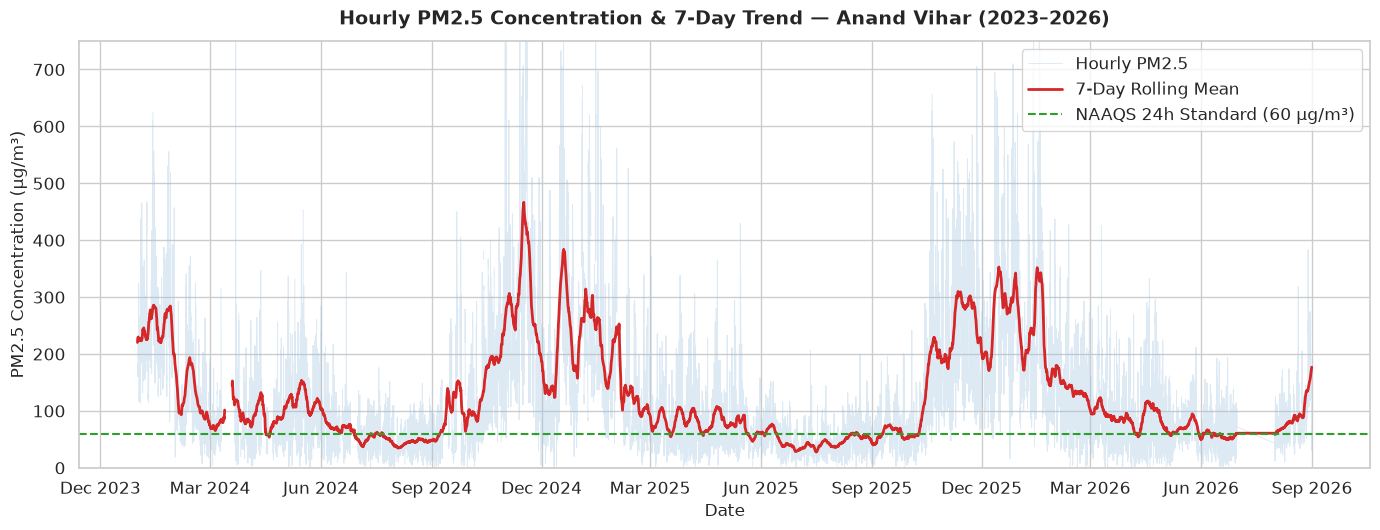

In [7]:
# Filter Anand Vihar station telemetry
av_data = df_caaqms[df_caaqms['station_name'] == 'Anand Vihar'].sort_values('datetime').copy()
av_data['pm25_7d_mean'] = av_data['pm25'].rolling(window=24*7, min_periods=24, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(av_data['datetime'], av_data['pm25'], color='#A0C4E2', alpha=0.35, linewidth=0.7, label='Hourly PM2.5')
ax.plot(av_data['datetime'], av_data['pm25_7d_mean'], color='#D62728', linewidth=2.0, label='7-Day Rolling Mean')

# Reference NAAQS Standard Line for PM2.5 (60 µg/m³ 24h standard)
ax.axhline(60, color='#2CA02C', linestyle='--', linewidth=1.5, label='NAAQS 24h Standard (60 µg/m³)')

ax.set_title('Hourly PM2.5 Concentration & 7-Day Trend — Anand Vihar (2023–2026)', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 Concentration (µg/m³)')
ax.set_ylim(0, 750)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


### B. $\text{PM}_{2.5}$ Comparison Across All 7 Delhi Stations
We compare particulate levels across all 7 monitoring stations to examine urban background levels versus heavy traffic hotspots.


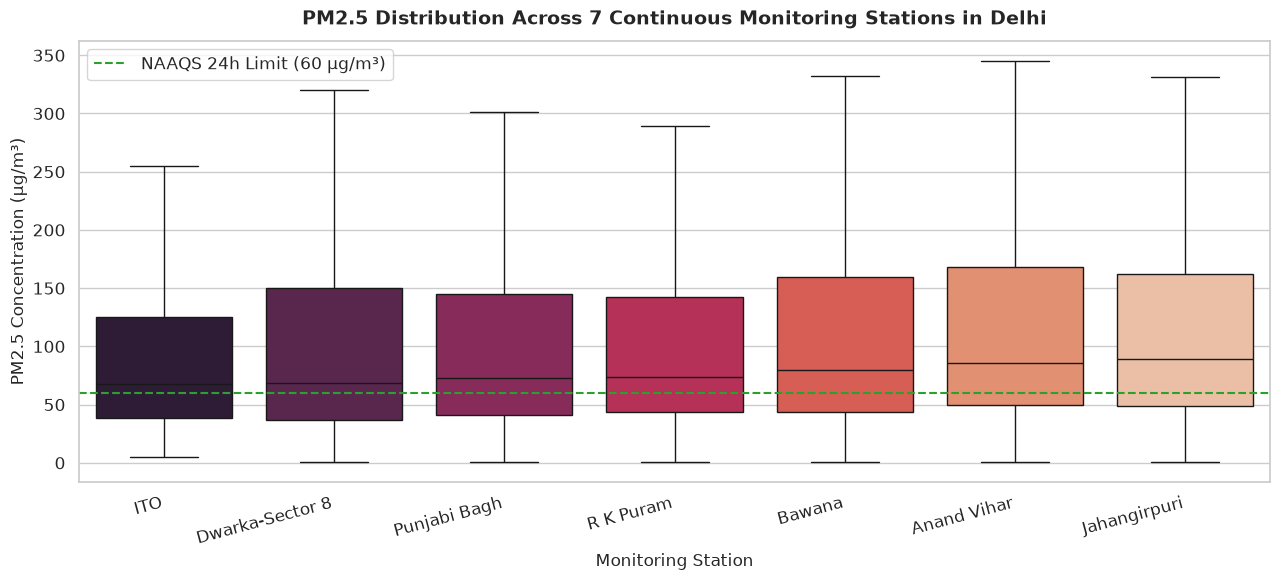

--- Station PM2.5 Concentration Statistics (µg/m³) ---


,Station,Mean,Median,75th Percentile,95th Percentile
3,ITO,96.63,67.25,125.25,269.00
2,Dwarka-Sector 8,106.88,68.62,150.00,304.21
5,Punjabi Bagh,109.72,73.00,145.00,318.00
6,R K Puram,108.92,74.00,142.25,305.00
1,Bawana,117.88,80.00,159.25,331.96
0,Anand Vihar,126.19,86.00,168.00,353.50
4,Jahangirpuri,123.62,88.75,162.00,345.00


In [8]:
# Calculate station-level summary
station_pm_stats = df_caaqms.groupby('station_name')['pm25'].agg(
    ['mean', 'median', lambda x: np.percentile(x.dropna(), 75), lambda x: np.percentile(x.dropna(), 95)]
).reset_index()
station_pm_stats.columns = ['Station', 'Mean', 'Median', '75th Percentile', '95th Percentile']
station_pm_stats = station_pm_stats.sort_values('Median', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('rocket', n_colors=7)

sns.boxplot(
    data=df_caaqms,
    x='station_name',
    y='pm25',
    order=station_pm_stats['Station'],
    palette=palette,
    showfliers=False,
    ax=ax
)

ax.axhline(60, color='#2CA02C', linestyle='--', linewidth=1.5, label='NAAQS 24h Limit (60 µg/m³)')
ax.set_title('PM2.5 Distribution Across 7 Continuous Monitoring Stations in Delhi', pad=12)
ax.set_xlabel('Monitoring Station')
ax.set_ylabel('PM2.5 Concentration (µg/m³)')
ax.legend(loc='upper left', frameon=True)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("--- Station PM2.5 Concentration Statistics (µg/m³) ---")
display(station_pm_stats.round(2))


### C. Diurnal Hourly $\text{PM}_{2.5}$ Pattern (24-Hour Cycle)
Air pollution exhibits strong diurnal patterns driven by boundary layer height dynamics and traffic cycles.


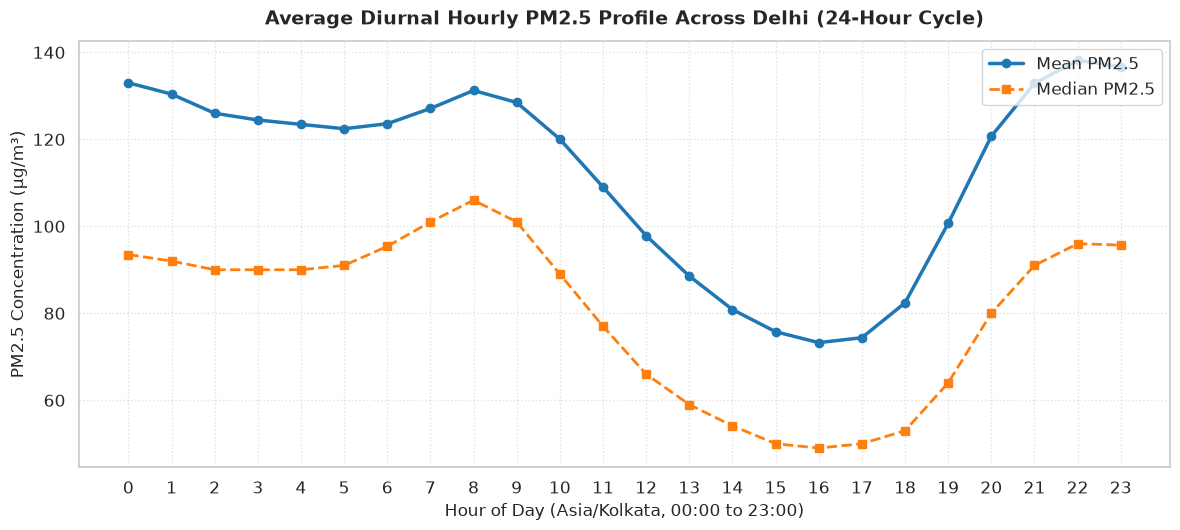

In [9]:
# Compute average hourly profile across all stations
diurnal_profile = df_caaqms.groupby('hour')['pm25'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(diurnal_profile['hour'], diurnal_profile['mean'], marker='o', color='#1F77B4', linewidth=2.5, label='Mean PM2.5')
ax.plot(diurnal_profile['hour'], diurnal_profile['median'], marker='s', color='#FF7F0E', linewidth=2.0, linestyle='--', label='Median PM2.5')

ax.set_title('Average Diurnal Hourly PM2.5 Profile Across Delhi (24-Hour Cycle)', pad=12)
ax.set_xlabel('Hour of Day (Asia/Kolkata, 00:00 to 23:00)')
ax.set_ylabel('PM2.5 Concentration (µg/m³)')
ax.set_xticks(range(0, 24))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


### D. 2025 Continuous AQI Distribution
We visualize the density and distribution of official continuous AQI values across all stations in 2025, marking the CPCB regulatory tier boundaries.


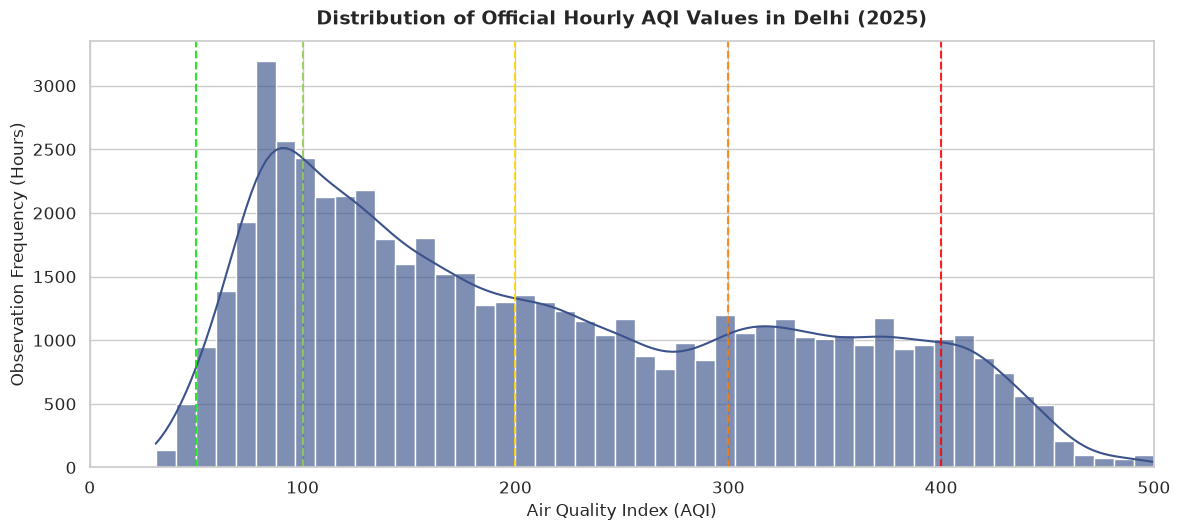

In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5))

sns.histplot(
    df_aqi['aqi_value'].dropna(),
    bins=50,
    kde=True,
    color='#3B528B',
    edgecolor='white',
    alpha=0.65,
    ax=ax
)

# CPCB Category threshold lines
cpcb_tiers = [
    (50, 'Good (0-50)', '#00E400'),
    (100, 'Satisfactory (51-100)', '#92D050'),
    (200, 'Moderate (101-200)', '#FFD700'),
    (300, 'Poor (201-300)', '#FF7E00'),
    (400, 'Very Poor (301-400)', '#FF0000'),
]

for val, label, color in cpcb_tiers:
    ax.axvline(val, color=color, linestyle='--', linewidth=1.5, alpha=0.85)

ax.set_title('Distribution of Official Hourly AQI Values in Delhi (2025)', pad=12)
ax.set_xlabel('Air Quality Index (AQI)')
ax.set_ylabel('Observation Frequency (Hours)')
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()


### E. Official CPCB AQI Category Breakdown
We quantify the proportion of total monitoring hours spent in each official CPCB category during 2025.


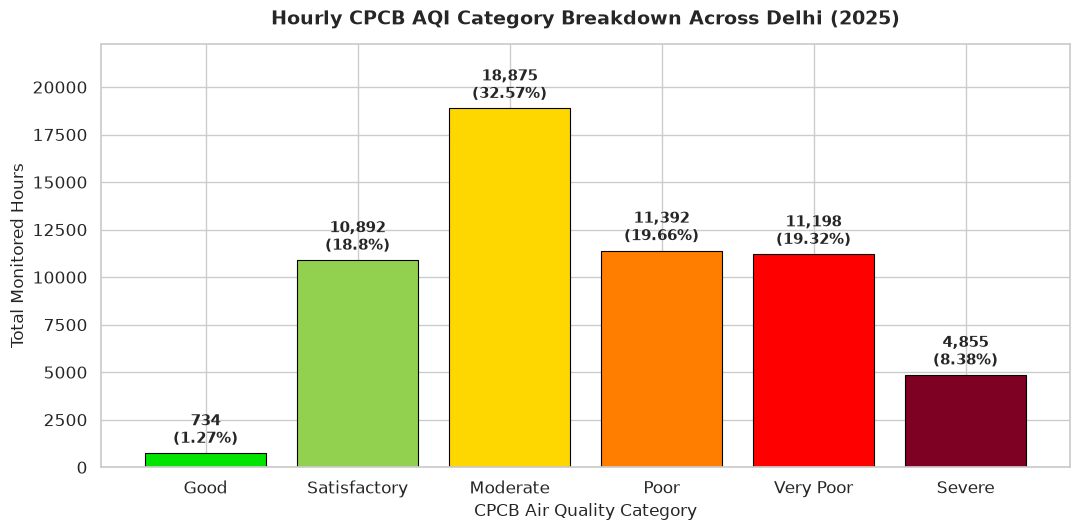

--- CPCB Category Frequency Table ---


,Category,Hours,Percentage
0,Good,734,1.27
1,Satisfactory,10892,18.80
2,Moderate,18875,32.57
3,Poor,11392,19.66
4,Very Poor,11198,19.32
5,Severe,4855,8.38


In [11]:
# Count hours per category
cat_counts = df_aqi['aqi_category'].value_counts(sort=False).reset_index()
cat_counts.columns = ['Category', 'Hours']
cat_counts['Percentage'] = (cat_counts['Hours'] / cat_counts['Hours'].sum() * 100).round(2)

cpcb_colors = {
    'Good': '#00E400',
    'Satisfactory': '#92D050',
    'Moderate': '#FFD700',
    'Poor': '#FF7E00',
    'Very Poor': '#FF0000',
    'Severe': '#7E0023'
}

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(
    cat_counts['Category'],
    cat_counts['Hours'],
    color=[cpcb_colors[c] for c in cat_counts['Category']],
    edgecolor='black',
    linewidth=0.8
)

# Add percentage annotations on top of each bar
for bar, pct in zip(bars, cat_counts['Percentage']):
    height = bar.get_height()
    ax.annotate(
        f"{height:,}\n({pct}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=10.5,
        fontweight='bold'
    )

ax.set_title('Hourly CPCB AQI Category Breakdown Across Delhi (2025)', pad=14)
ax.set_xlabel('CPCB Air Quality Category')
ax.set_ylabel('Total Monitored Hours')
ax.set_ylim(0, cat_counts['Hours'].max() * 1.18)
plt.tight_layout()
plt.show()

print("--- CPCB Category Frequency Table ---")
display(cat_counts)


## 6. Example Insights

The exploratory analysis reveals several clear, data-supported patterns:

1. **Extreme Seasonal Spikes in Winter:** Particulate concentrations ($\text{PM}_{2.5}$) rise dramatically between November and January, regularly exceeding $300\text{--}600\ \mu\text{g/m}^3$, contrasted with relatively clean conditions during the summer monsoon (July–August) where $\text{PM}_{2.5}$ drops below $30\text{--}50\ \mu\text{g/m}^3$.
2. **Bimodal Diurnal Pattern:** Across all stations, particulate pollution reaches dual daily peaks—the first in the morning (08:00–10:00) during rush hour and shallow boundary layer, and a second, larger peak late at night (22:00–02:00) driven by nighttime surface cooling and commercial truck transit.
3. **High Spatial Synchrony:** While Anand Vihar and Jahangirpuri record higher absolute median concentrations due to local traffic/industrial activity, all 7 stations exhibit synchronized macro-temporal trends, demonstrating that Delhi operates as a cohesive regional airshed.
4. **Significant High-Risk Exposure:** In 2025, approximately **47.4%** of all monitored station-hours fell into the **Poor (19.7%)**, **Very Poor (19.3%)**, or **Severe (8.4%)** risk categories, highlighting sustained public health vulnerability.


## 7. Using This Dataset for Further Analysis

This curated dataset is ideal for a broad range of environmental data science, time-series forecasting, and econometric policy evaluation tasks:

- **Time-Series Forecasting:** Build multi-horizon prediction models (e.g. 1-hour ahead, 6-hours ahead, and 24-hours ahead) for $\text{PM}_{2.5}, \text{PM}_{10}$, or composite AQI using regression, tree models (LightGBM, XGBoost), or deep learning architectures (LSTMs, Temporal Fusion Transformers).
- **Causal Policy Evaluation:** Apply econometric methods (e.g. Interrupted Time Series, Synthetic Control, or Difference-in-Differences) to evaluate the empirical impact of episodic environmental regulations (such as Graded Response Action Plan [GRAP] stages, festive firecracker bans, and odd-even traffic rules).
- **Spatial & Dispersion Modeling:** Model pollutant transport and cross-station spatial correlations across Delhi's urban basin.
- **Meteorological Coupling:** Investigate the non-linear interactions between atmospheric temperature, relative humidity, wind velocity vectors, solar irradiance, and particulate accumulation.
- **Cost-Sensitive Risk Classification:** Develop early-warning systems optimized for high-penalty public health events (e.g. predicting severe smog crises $\ge 401$ AQI 24 hours in advance).


## 8. Data Provenance & Citation

### Data Origin
The raw environmental telemetry was collected by the **Continuous Ambient Air Quality Monitoring Station (CAAQMS)** network and official AQI bulletins published by:
- **Central Pollution Control Board (CPCB)**, Ministry of Environment, Forest and Climate Change, Government of India.
- **Delhi Pollution Control Committee (DPCC)**, Government of NCT of Delhi.
- Portals: [CPCB CAAQMS Portal](https://airquality.cpcb.gov.in/caaqms/) and [Open Government Data (OGD) Platform India](https://data.gov.in/).

### License
This dataset is distributed under the terms of the Open Government Data (OGD) Platform India. When utilizing this dataset for research, modeling, or public analysis, please cite the CPCB and DPCC monitoring authorities.

### Citation
```bibtex
@dataset{delhi_air_quality_hourly_2023_2026,
  title={Delhi Air Quality Monitoring Dataset (Hourly, 2023--2026)},
  author={Delhi Pollution Control Committee and Central Pollution Control Board},
  editor={Siddharth},
  year={2026},
  publisher={Kaggle},
  url={https://www.kaggle.com/datasets/siddharthdongardive/delhi-air-quality-monitoring-dataset-2023-2026}
}
```


## 9. Dataset Files Summary Table

| File Name | Rows | Columns | Description |
|---|:---:|:---:|---|
| **`caaqms_hourly.csv`** | 162,096 | 24 | Curated hourly observations of 12 air pollutants and 8 meteorological variables (2023–2026) with non-destructive QC audit flags. |
| **`aqi_hourly.csv`** | 57,946 | 5 | Official CPCB-calculated hourly Air Quality Index (0–500 scale) for all 7 stations throughout 2025. |
| **`stations.csv`** | 7 | 6 | Monitoring station metadata (station ID, official name, city, operating agency). |
| **`source_files.csv`** | 105 | 9 | Data provenance tracking observations back to original government telemetry source batches. |
| **`column_metadata.csv`** | 44 | 5 | Machine-readable column definitions specifying descriptions, measurement units, and data types. |

---
*Created for the Kaggle Dataset: [Delhi Air Quality Monitoring Dataset (Hourly, 2023–2026)](https://www.kaggle.com/datasets/siddharthdongardive/delhi-air-quality-monitoring-dataset-2023-2026).*
